# DeepMID — Colab Training Pipeline (GPU T4)
Calls `generador_espectros.py`, `preprocesador_dataset.py` and `deepmid_pytorch.py`
from Google Drive.

## Cell 1 — Mount Drive + install dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Install non-standard dependencies
!pip install nmrglue tqdm openpyxl scikit-learn --quiet

import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4


## Cell 2 — Add Drive path to sys.path + imports

In [2]:
import sys
import os

# Path where your .py files are in Drive — change if needed
DRIVE_ROOT = "/content/drive/MyDrive/Simulacion RMN"
sys.path.append(DRIVE_ROOT)

import torch
import numpy as np
from datetime import datetime

# Pipeline
from generador_espectros import (
    load_individual_spectra,
    load_metabolic_profile,
    load_internal_standard,
    match_spectra_to_metadata,
    normalize_name,
)
from preprocesador_dataset import (
    load_metadata_individual,
    build_individual_cache,
    build_full_dataset,
)

# Model
from deepmid_pytorch import (
    DeepMID,
    train_deepmid,
    mc_dropout_predict,
    save_run,
    load_run,
    set_seeds,
)

print('All imports OK')

All imports OK


## Cell 3 — Parameters

In [3]:
# ── General ──────────────────────────────────────────────────
ROOT_DIR    = DRIVE_ROOT
RESULTS_DIR = os.path.join(ROOT_DIR, "Resultados", "Modelos")
RANDOM_SEED = 42
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ── File paths — individual spectra metadata ──────────────────
META_IND_PATH = os.path.join(ROOT_DIR, "data set", "metadata_espectros_individuales_con_TSP sodico(SI).xlsx")
IND_DIR = os.path.join(ROOT_DIR, "Espectros individuales + TSP sodico (SI)")

# ── File paths — generador_espectros inputs ───────────────────
EXCEL_FILENAME      = "Perfil metabolico vino.xlsx"
EXCEL_SHEET         = "General"
INTERNAL_STD_FILE   = "tsp-d4 sodico.csv"
INTERNAL_STD_FOLDER = "Moleculas mol"
SPECTRA_SUBFOLDER   = os.path.join("Moleculas mol", "Espectros individuales")
SPECTRA_EXT         = ".csv"

# ── Dataset split ─────────────────────────────────────────────
N_TOTAL    = 4000
TRAIN_FRAC = 0.70
VALID_FRAC = 0.15

# ── Preprocessing ─────────────────────────────────────────────
PPM_IS    = 0.0
WINDOW_IS = 0.2
PPM_MIN   = 0.0
PPM_MAX   = 10.0
BIN_FACTOR = 4   # 1=sin binning, 2, 4 recomendados

# ── Mixture generation ────────────────────────────────────────
MAX_SHIFT_PTS       = 60
APLICAR_DEFORMACION = False
REF_REFERENCE_PPM   = None
PCT_NO_PHASE        = 0.30
PCT_MAX_PEAK        = 0.20
PCT_REF_PEAK        = 0.15
PCT_PROM_PEAK       = 0.20
PCT_CENTER          = 0.15
PHI0_RANGE          = (-15.0, 15.0)
PHI1_RANGE          = (-3.0,   3.0)

# ── Model hyperparameters ─────────────────────────────────────
NUM_CONV_LAYERS = 8
POOL_EVERY      = 2
POOL_LIST       = [1, 2, 3, 4]
DROPOUT         = 0.2

# ── Training hyperparameters ──────────────────────────────────
EPOCHS     = 50
BATCH_SIZE = 32
LR         = 1e-4
PATIENCE   = 8
MIN_DELTA  = 1e-3

# ── MC Dropout ────────────────────────────────────────────────
MC_N_SAMPLES  = 30
MC_BATCH_SIZE = 64

Device: cuda


## Cell 4 — Load pipeline data


In [4]:
standardsSpec, standardsDictionary, x_ref = load_individual_spectra(root_dir= ROOT_DIR,subfolder = SPECTRA_SUBFOLDER, ext  = SPECTRA_EXT,)
df = load_metabolic_profile( root_dir = ROOT_DIR, filename   = EXCEL_FILENAME, sheet_name = EXCEL_SHEET,)
ppm_std, v_std = load_internal_standard(root_dir  = ROOT_DIR, filename  = INTERNAL_STD_FILE, subfolder = INTERNAL_STD_FOLDER,)
master_df, diagnostics = match_spectra_to_metadata( df = df,
    standardsDictionary = standardsDictionary,
)
ppm_axis = x_ref

print(f"Matched : {diagnostics['matched']} / {diagnostics['total']}")
if diagnostics['missing'] > 0:
    print("Unmatched:")
    print(diagnostics['missing_df'])

Matched : 17 / 17


## Cell 5 — Load and cache individual spectra

In [6]:
meta_ind, comp_to_file = load_metadata_individual(META_IND_PATH)
print(f"Compounds in metadata: {len(meta_ind)}")

ind_cache = build_individual_cache(
    meta_ind       = meta_ind,
    ind_dir        = IND_DIR,
    comp_to_file   = comp_to_file,
    ppm_is_nominal = PPM_IS,
    window_is      = WINDOW_IS,
    ppm_min        = PPM_MIN,
    ppm_max        = PPM_MAX,
    bin_factor = BIN_FACTOR,
)
print(f"Cached: {len(ind_cache)} individual spectra")

# Build compound name → idx mapping
master_norm_to_real = {normalize_name(n): n for n in master_df["Compuesto"].tolist()}
ind_to_master_idx   = {}
for comp_name in ind_cache.keys():
    norm = normalize_name(comp_name)
    if norm in master_norm_to_real:
        master_name = master_norm_to_real[norm]
        idx = master_df.loc[master_df["Compuesto"] == master_name, "idx"].values[0]
        ind_to_master_idx[comp_name] = int(idx)

print(f"\nMatched compounds:")
for name, idx in ind_to_master_idx.items():
    print(f"  {name:<30} -> idx {idx}")

Compounds in metadata: 8
Cached: 8 individual spectra

Matched compounds:
  acido acetico                  -> idx 1
  acido citrico                  -> idx 2
  acido lactico                  -> idx 4
  acido oxalico                  -> idx 6
  acido tartarico                -> idx 8
  fructosa                       -> idx 10
  sacarosa                       -> idx 16
  glucosa                        -> idx 12


## Cell 6 — Generate datasets

In [ ]:
set_seeds(RANDOM_SEED)

aug_train, aug_valid, aug_test = build_full_dataset(
    master_df         = master_df,
    standardsSpec     = standardsSpec,
    ppm_axis          = ppm_axis,
    v                 = v_std,
    ind_cache         = ind_cache,
    ind_to_master_idx = ind_to_master_idx,
    n_total           = N_TOTAL,
    train_frac        = TRAIN_FRAC,
    valid_frac        = VALID_FRAC,
    max_shift         = MAX_SHIFT_PTS,
    ppm_is_nominal    = PPM_IS,
    window_is         = WINDOW_IS,
    ppm_min           = PPM_MIN,
    ppm_max           = PPM_MAX,
    random_seed       = RANDOM_SEED,
    bin_factor = BIN_FACTOR,
    mixture_kwargs    = dict(
        aplicar_deformacion = APLICAR_DEFORMACION,
        REF_REFERENCE_PPM   = REF_REFERENCE_PPM,
        PCT_NO_PHASE        = PCT_NO_PHASE,
        PCT_MAX_PEAK        = PCT_MAX_PEAK,
        PCT_REF_PEAK        = PCT_REF_PEAK,
        PCT_PROM_PEAK       = PCT_PROM_PEAK,
        PCT_CENTER          = PCT_CENTER,
        phi0_range          = PHI0_RANGE,
        phi1_range          = PHI1_RANGE,
    )
)

print(f"Train : R={aug_train['R'].shape}  S={aug_train['S'].shape}  y={aug_train['y'].shape}")
print(f"Valid : R={aug_valid['R'].shape}  S={aug_valid['S'].shape}  y={aug_valid['y'].shape}")
print(f"Test  : R={aug_test['R'].shape}   S={aug_test['S'].shape}   y={aug_test['y'].shape}")

for name, aug in [("Train", aug_train), ("Valid", aug_valid), ("Test", aug_test)]:
    n_pos = (aug['y'] == 1).sum()
    n_neg = (aug['y'] == 0).sum()
    print(f"{name} — present: {n_pos} ({100*n_pos/len(aug['y']):.1f}%)  "
          f"absent: {n_neg} ({100*n_neg/len(aug['y']):.1f}%)")

Split sizes — train: 2800 | valid: 600 | test: 600

── Building TRAIN split ──


Generating pairs (R, S, y):  22%|██▏       | 615/2800 [01:51<08:58,  4.06it/s]

## Cell 7 — Build model + shape check

In [7]:
set_seeds(RANDOM_SEED)

model = DeepMID(num_conv_layers = NUM_CONV_LAYERS, pool_every= POOL_EVERY, pool_list= POOL_LIST, dropout= DROPOUT,)

L         = aug_train['R'].shape[1]
dummy_R   = torch.zeros(2, L)
dummy_S   = torch.zeros(2, L)
dummy_out = model(dummy_R, dummy_S)

print(f"Input shape  : (2, {L})")
print(f"Output shape : {dummy_out.shape}")
print(f"Total params : {sum(p.numel() for p in model.parameters()):,}")
print(f"Device       : {DEVICE}")

Input shape  : (2, 27307)
Output shape : torch.Size([2, 1])
Total params : 1,101,201
Device       : cuda


## Cell 8 — Train

In [8]:
os.makedirs(RESULTS_DIR, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir   = os.path.join(RESULTS_DIR, f"deepmid_{timestamp}")
os.makedirs(run_dir, exist_ok=True)

history = train_deepmid(model= model,aug_train  = aug_train, aug_valid= aug_valid,epochs= EPOCHS,batch_size = BATCH_SIZE, lr = LR,patience= PATIENCE,min_delta  = MIN_DELTA,save_path  = os.path.join(run_dir, "deepmid.best.pt"), device= DEVICE,)

Training on: CUDA
Training on: CUDA
Train batches/epoch: 219 | Valid batches/epoch: 24
───────────────────────────────────────────────────────────────────────────


Epoch   1/50 | loss: 0.6861  acc: 0.5520 | val_loss: 0.6892  val_acc: 0.5387 | 73.0s  ✓ best
  ✓ Best weights saved (val_acc=0.5387)


Epoch   2/50 | loss: 0.6396  acc: 0.6194 | val_loss: 0.5352  val_acc: 0.6440 | 78.4s  ✓ best
  ✓ Best weights saved (val_acc=0.6440)


Epoch   3/50 | loss: 0.4317  acc: 0.7311 | val_loss: 0.3341  val_acc: 0.8100 | 78.4s  ✓ best
  ✓ Best weights saved (val_acc=0.8100)


Epoch   4/50 | loss: 0.3162  acc: 0.7961 | val_loss: 0.2803  val_acc: 0.8107 | 78.6s


...

Epoch  11/50 | loss: 0.2312  acc: 0.8567 | val_loss: 0.2232  val_acc: 0.8467 | 78.5s


Epoch  12/50 | loss: 0.2308  acc: 0.8516 | val_loss: 0.2237  val_acc: 0.8507 | 78.9s


Epoch  13/50 | loss: 0.2215  acc: 0.8484 | val_loss: 0.2133  val_acc: 0.8513 | 78.7s


Epoch  14/50 | loss: 0.2228  acc: 0.8554 | val_loss: 0.2305  val_acc: 0.8473 | 78.7s


Epoch  15/50 | loss: 0.2213  acc: 0.8527 | val_loss: 0.2161  val_acc: 0.8520 | 78.7s

Early stopping at epoch 15 (patience=8)

Best epoch: 7 | Best val_acc: 0.8593


## Cell 9 — Training curves

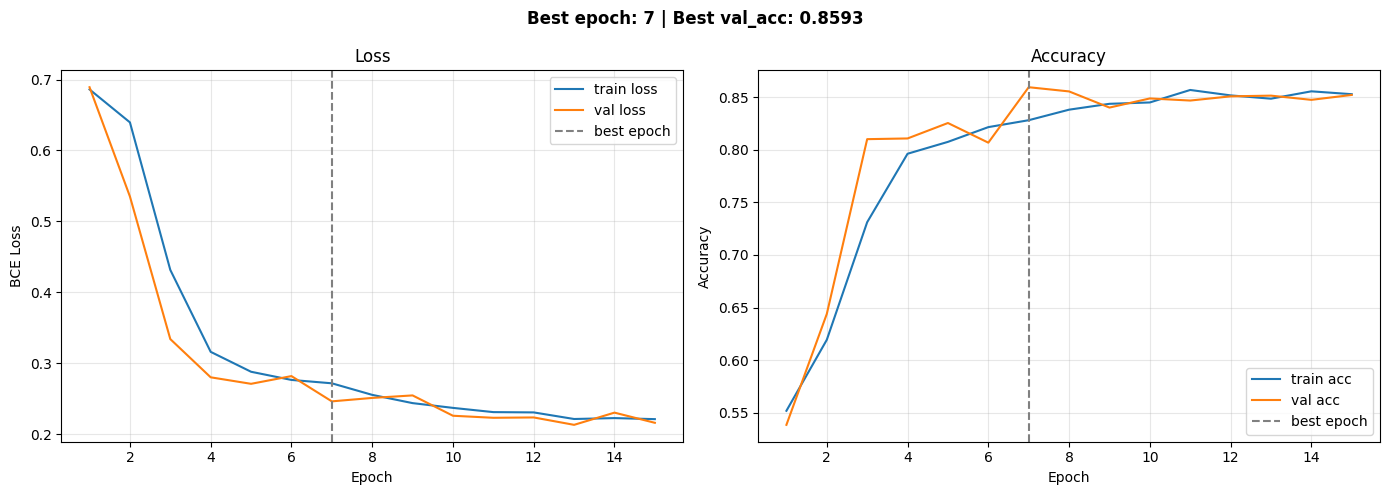

In [9]:
import matplotlib.pyplot as plt

epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ran, history['train_loss'], label='train loss')
ax1.plot(epochs_ran, history['val_loss'],   label='val loss')
ax1.axvline(history['best_epoch'] + 1, color='gray', linestyle='--', label='best epoch')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_ran, history['train_accuracy'], label='train acc')
ax2.plot(epochs_ran, history['val_accuracy'],   label='val acc')
ax2.axvline(history['best_epoch'] + 1, color='gray', linestyle='--', label='best epoch')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle(f"Best epoch: {history['best_epoch']+1} | Best val_acc: {history['best_val_acc']:.4f}",
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(run_dir, 'training_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

## Cell 10 — Save run

In [10]:
save_run(
    model         = model,
    history       = history,
    aug_train     = aug_train,
    aug_valid     = aug_valid,
    run_dir       = run_dir,
    model_name    = "deepmid",
    model_hparams = {
        "num_conv_layers": NUM_CONV_LAYERS,
        "pool_every"     : POOL_EVERY,
        "pool_list"      : POOL_LIST,
        "dropout"        : DROPOUT,
    },
    train_hparams = {
        "epochs"     : EPOCHS,
        "batch_size" : BATCH_SIZE,
        "lr"         : LR,
        "patience"   : PATIENCE,
        "min_delta"  : MIN_DELTA,
        "n_total"    : N_TOTAL,
        "train_frac" : TRAIN_FRAC,
        "valid_frac" : VALID_FRAC,
        "random_seed": RANDOM_SEED,
        "device"     : DEVICE,
    },
    notes = f"DeepMID PyTorch — Colab {DEVICE} — no contrastive loss.",
)
print(f"Run saved to: {run_dir}")

✓ Weights saved : /content/drive/MyDrive/Simulacion RMN/Resultados/Modelos/deepmid_20260430_165154/deepmid.best.pt
✓ JSON saved    : /content/drive/MyDrive/Simulacion RMN/Resultados/Modelos/deepmid_20260430_165154/info_modelo.json
Run saved to: /content/drive/MyDrive/Simulacion RMN/Resultados/Modelos/deepmid_20260430_165154


## Cell 11 — MC Dropout on test set

In [11]:
mean_p, std_p = mc_dropout_predict(model= model,aug= aug_test, n_samples= MC_N_SAMPLES, batch_size = MC_BATCH_SIZE, device= DEVICE,)

print(f"mean_p range : [{mean_p.min():.3f}, {mean_p.max():.3f}]")
print(f"std_p  range : [{std_p.min():.3f}, {std_p.max():.3f}]")
print(f"Samples      : {len(mean_p)}")

mean_p range : [0.000, 1.000]
std_p  range : [0.000, 0.211]
Samples      : 1500


## Cell 12 — Save MC Dropout results to Drive

In [12]:
import pickle

mc_results = {
    "mean_p"  : mean_p,
    "std_p"   : std_p,
    "aug_test": aug_test,
    "history" : history,
    "run_dir" : run_dir,
}

mc_path = os.path.join(run_dir, "mc_dropout_results.pkl")
with open(mc_path, "wb") as f:
    pickle.dump(mc_results, f)

print(f"MC results saved: {mc_path}")
print("You can now download this file and run analisis_resultados.py locally.")

MC results saved: /content/drive/MyDrive/Simulacion RMN/Resultados/Modelos/deepmid_20260430_165154/mc_dropout_results.pkl
You can now download this file and run analisis_resultados.py locally.


## Cell 13 — Load existing run (skip cells 7-12 to reload a saved model)

In [ ]:
# Uncomment and edit run_dir to reload a saved model
# run_dir = "/content/drive/MyDrive/Simulacion RMN/Resultados/Modelos/deepmid_20260429_120000"
# model, info = load_run(run_dir=run_dir, device=DEVICE)
# print(f"Best val_acc: {info['results']['best_val_acc']:.4f}")
print("Uncomment the lines above to reload a saved model.")

Cell 14 — Import análisis:


In [13]:
!pip install reportlab --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.4 MB/s eta 0:00:00


In [14]:
import importlib
import analisis_resultados
importlib.reload(analisis_resultados)
from analisis_resultados import generate_test_report, create_pdf_report
print("OK")

OK


Cell 15 — Generate report:


Generando reporte — 20260430_171426
Salida: /content/drive/MyDrive/Simulacion RMN/Resultados/analisis

Construyendo df_pairs...
Calculando escaneos...
Generando gráficos...


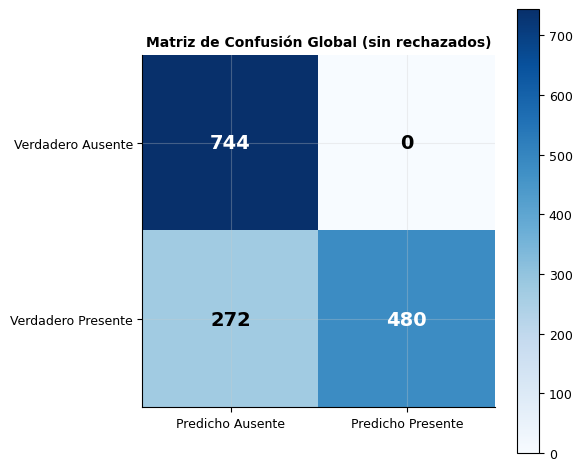

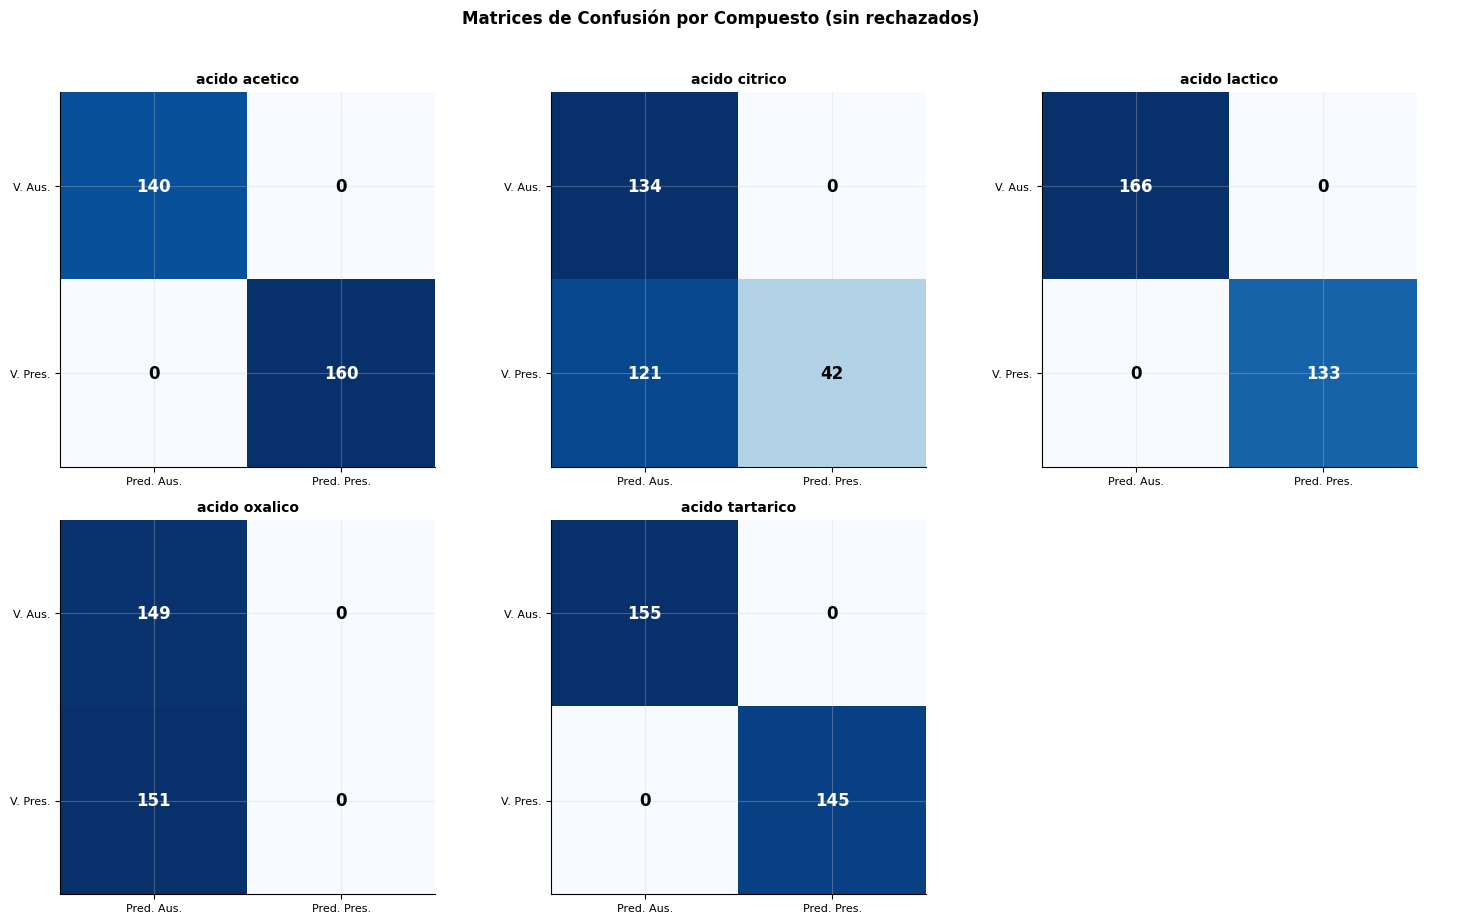

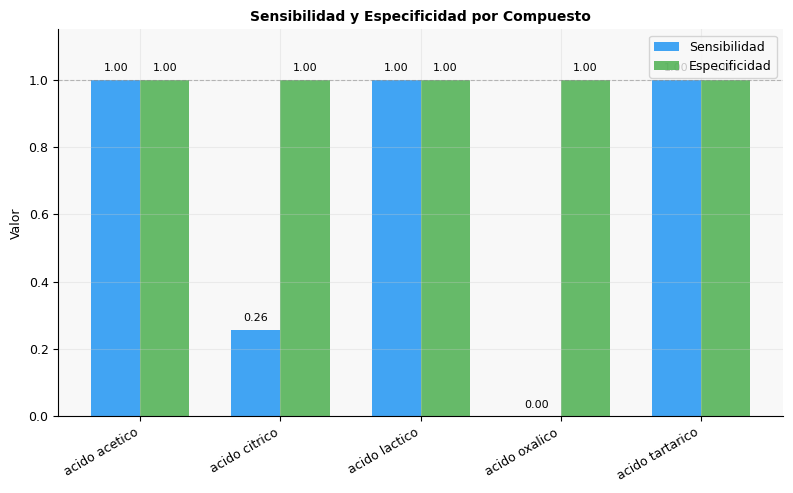

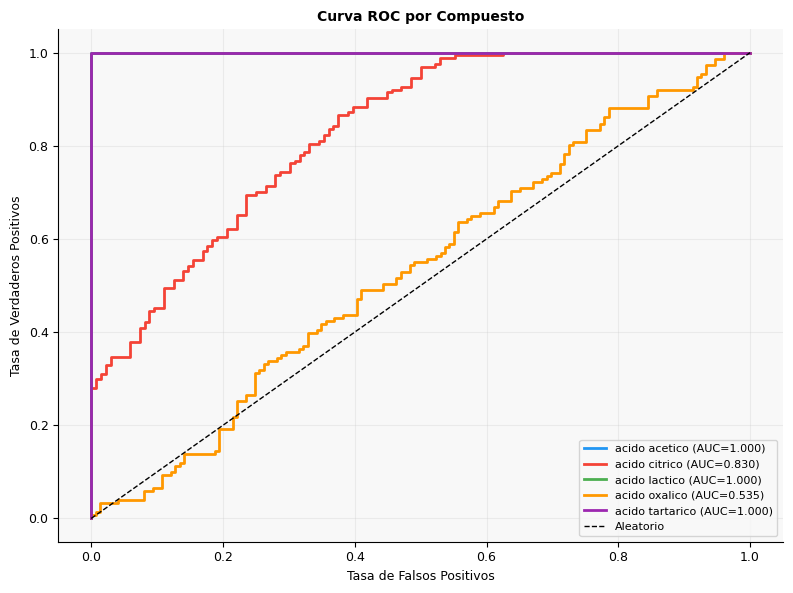

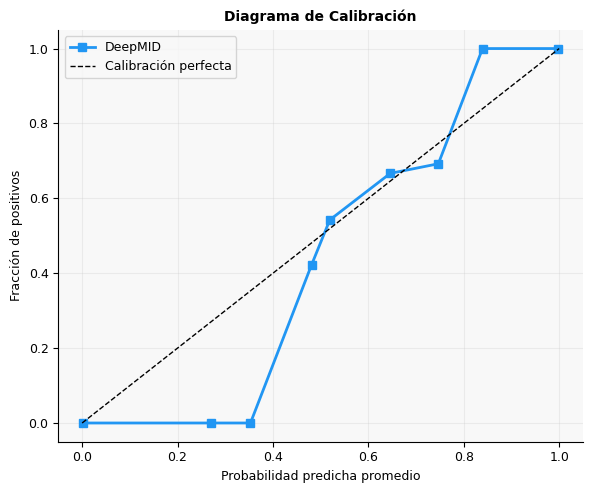

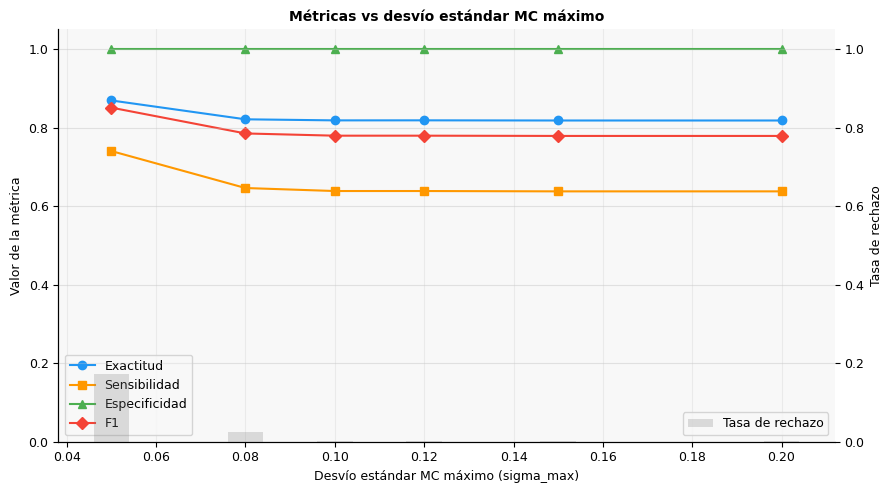

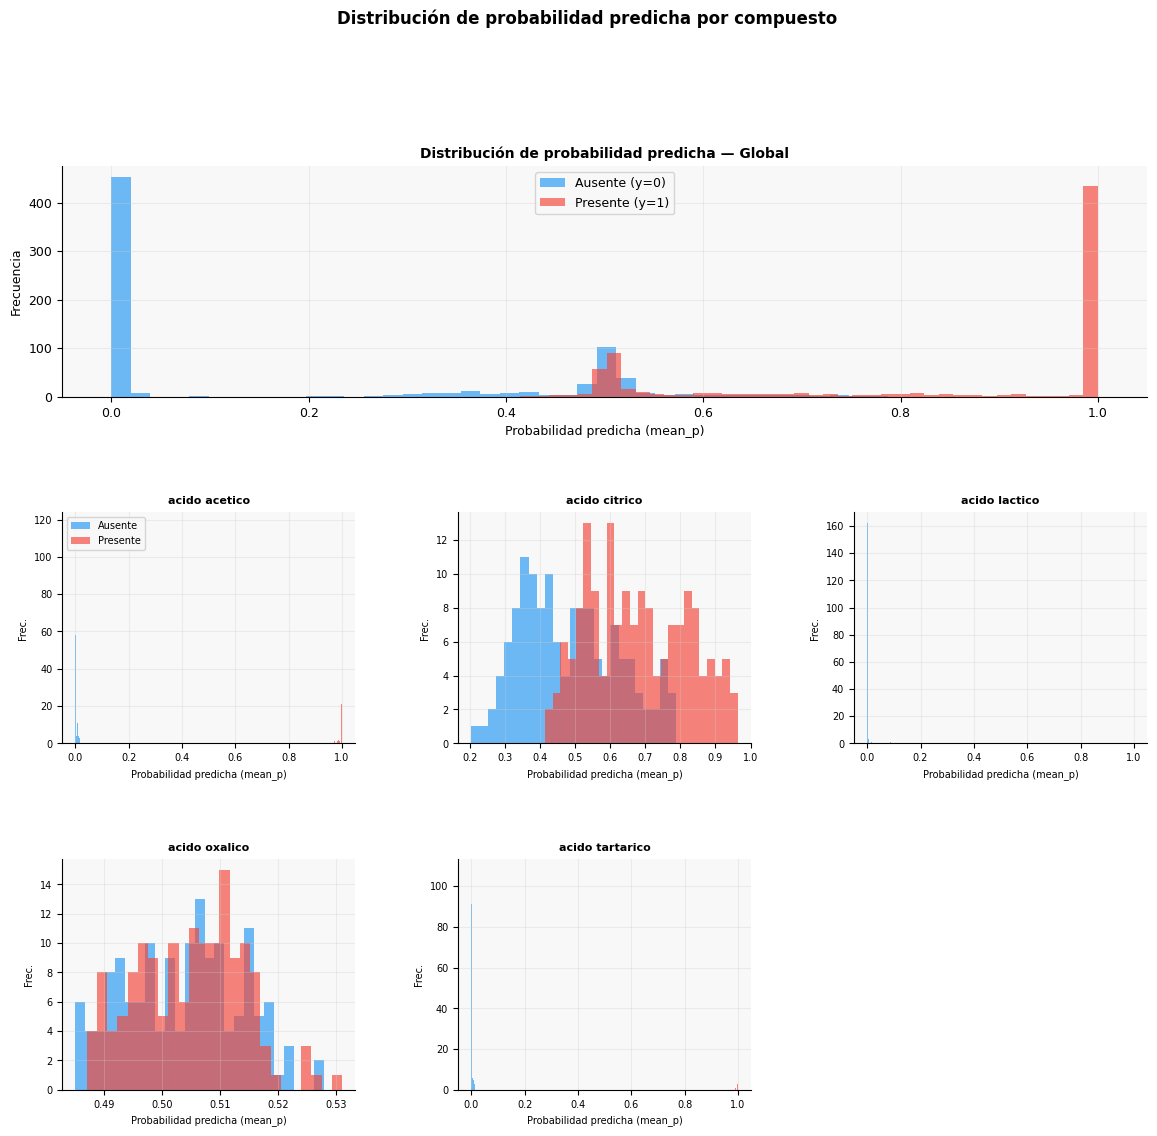

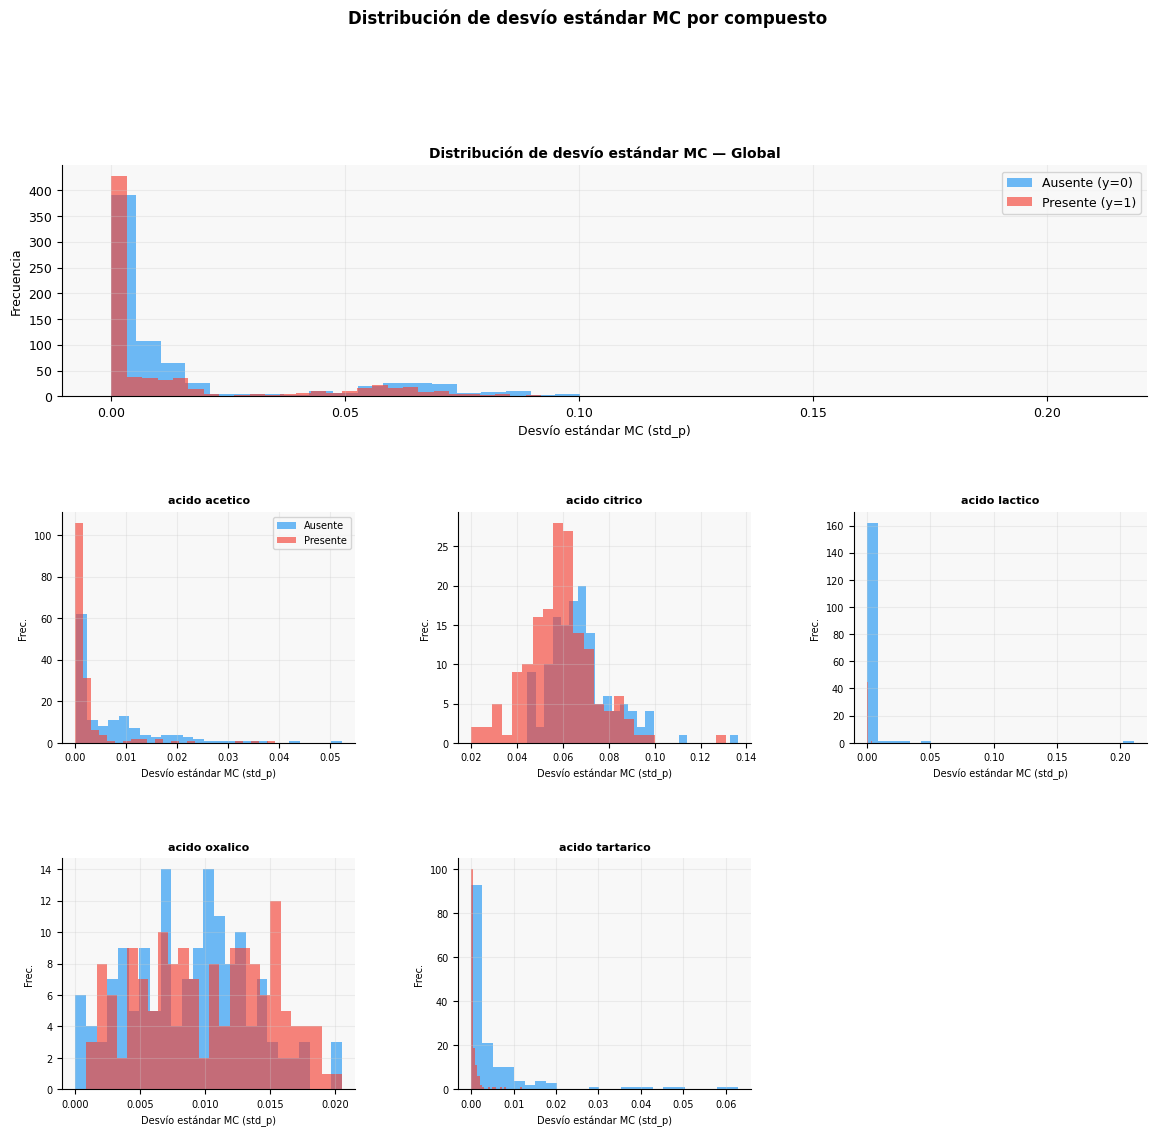

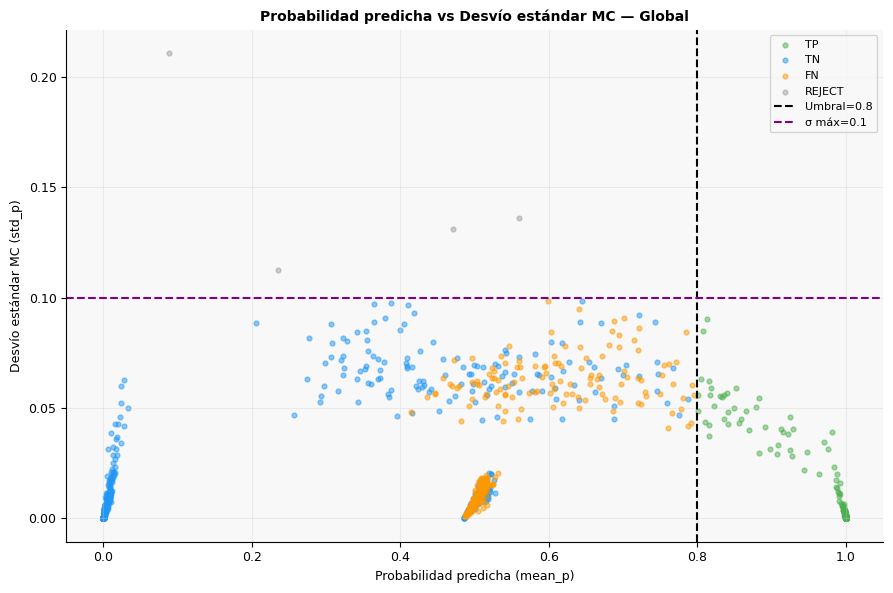

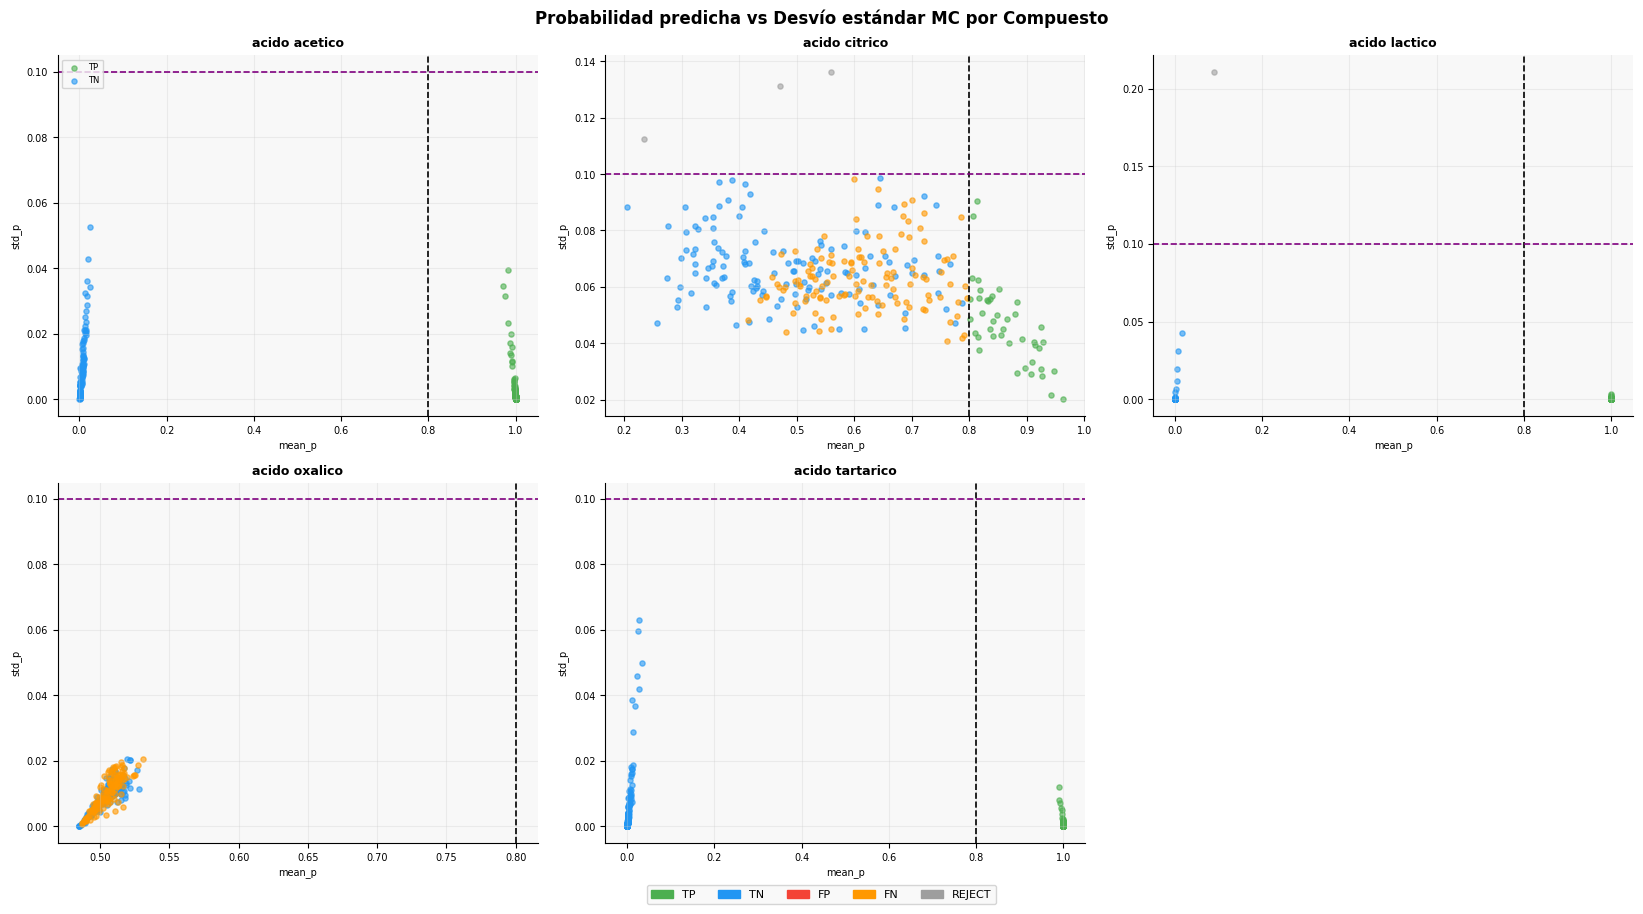

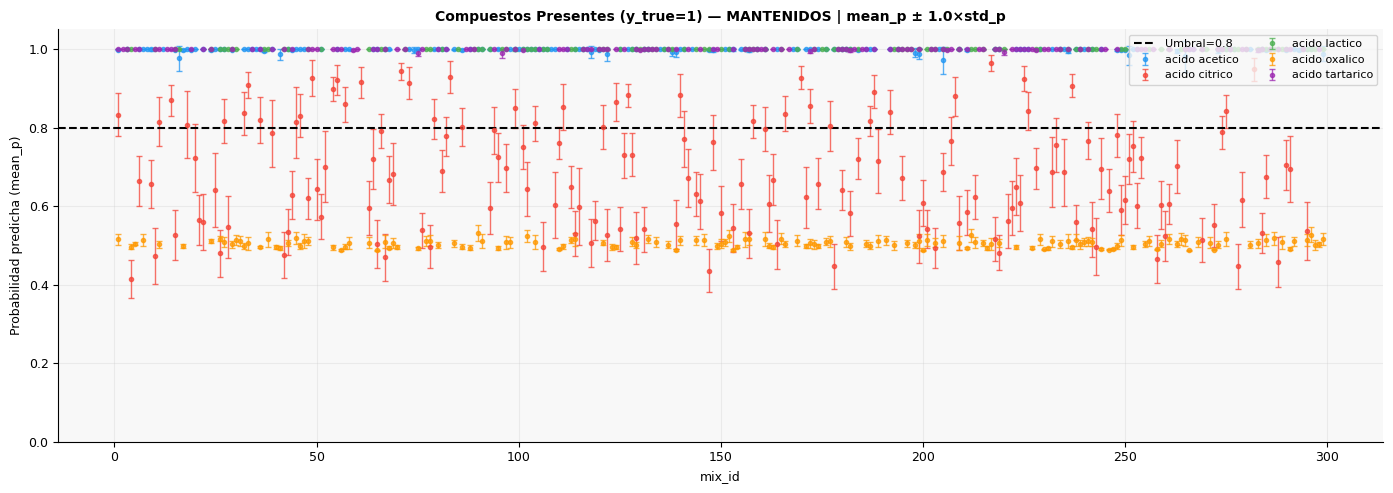

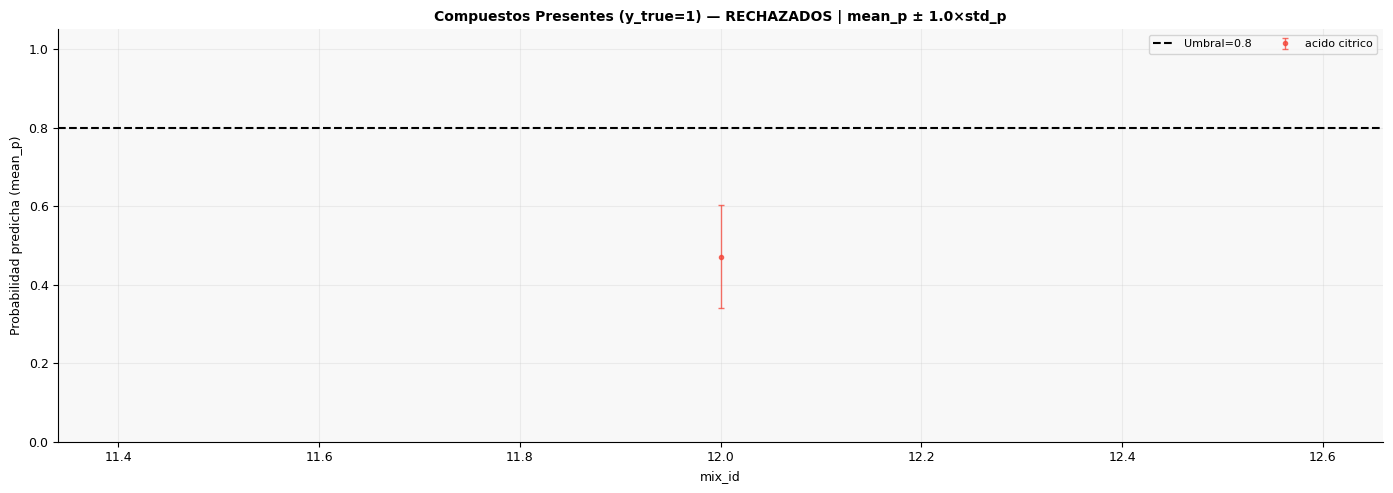

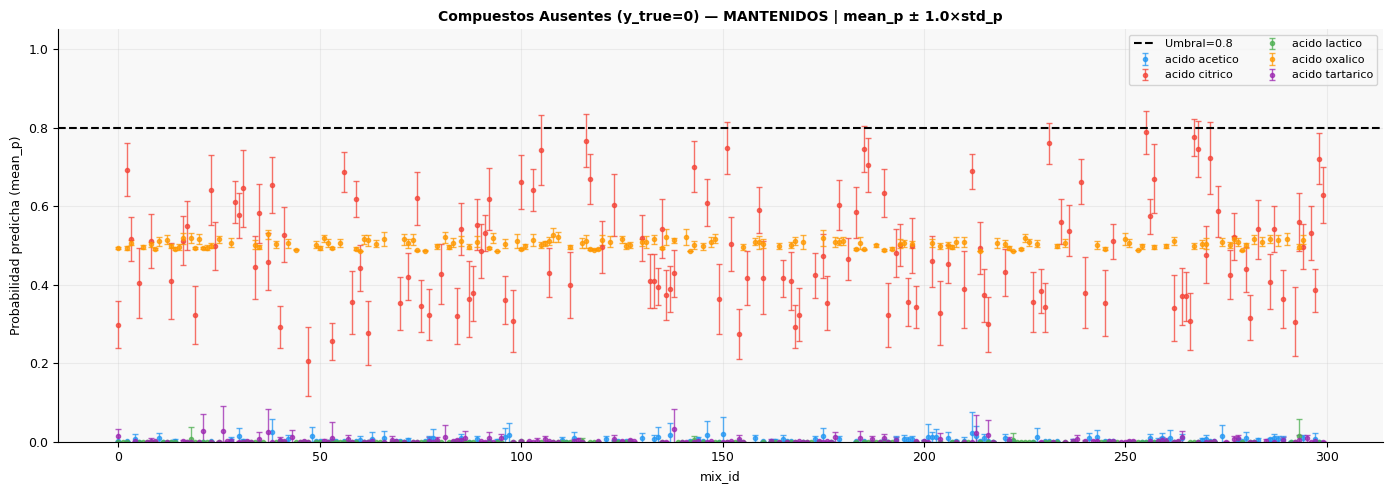

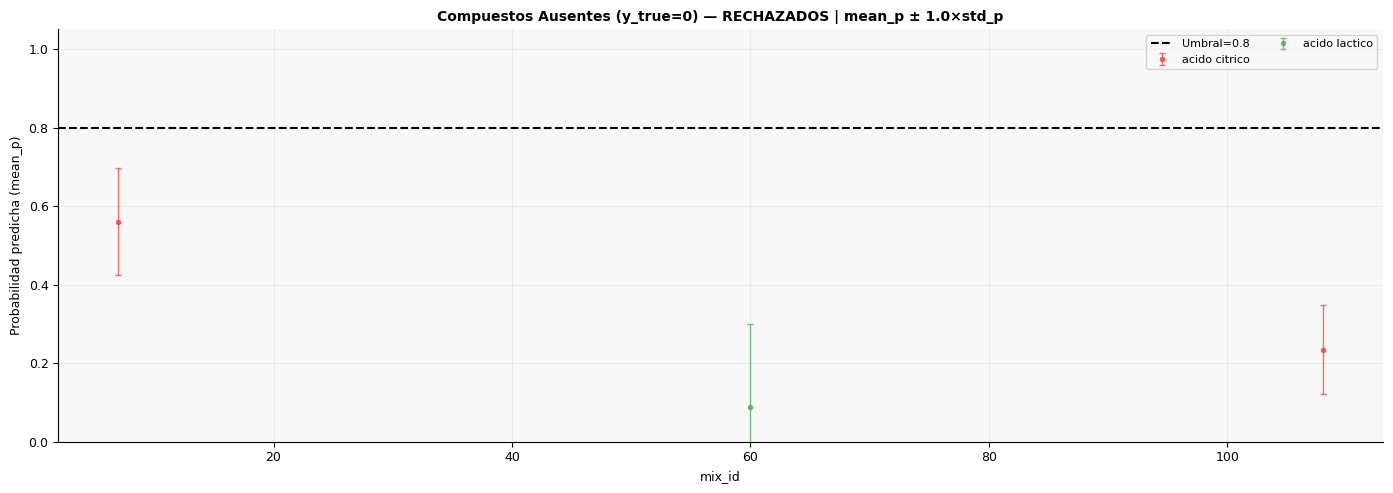

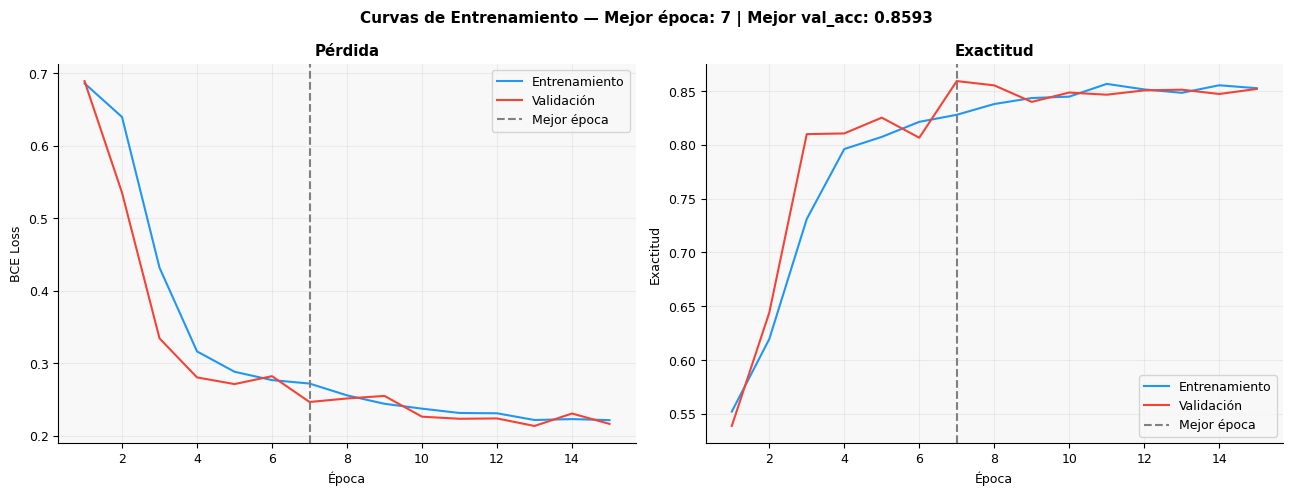

Generando análisis de co-ocurrencia...


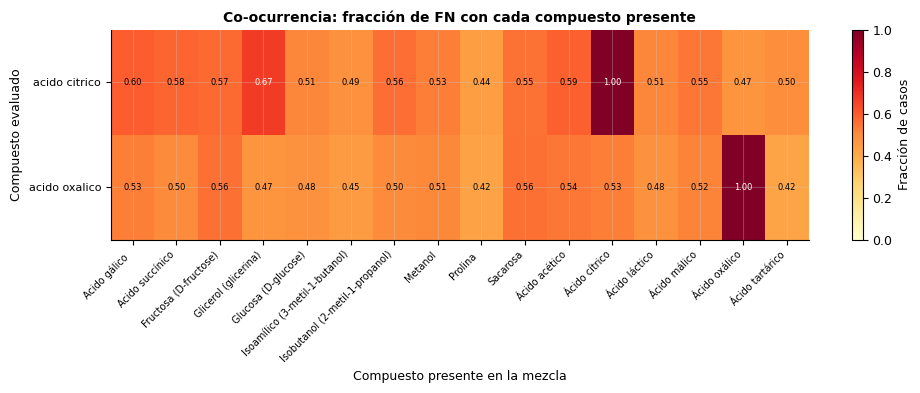

No cases with status in ['FP'].


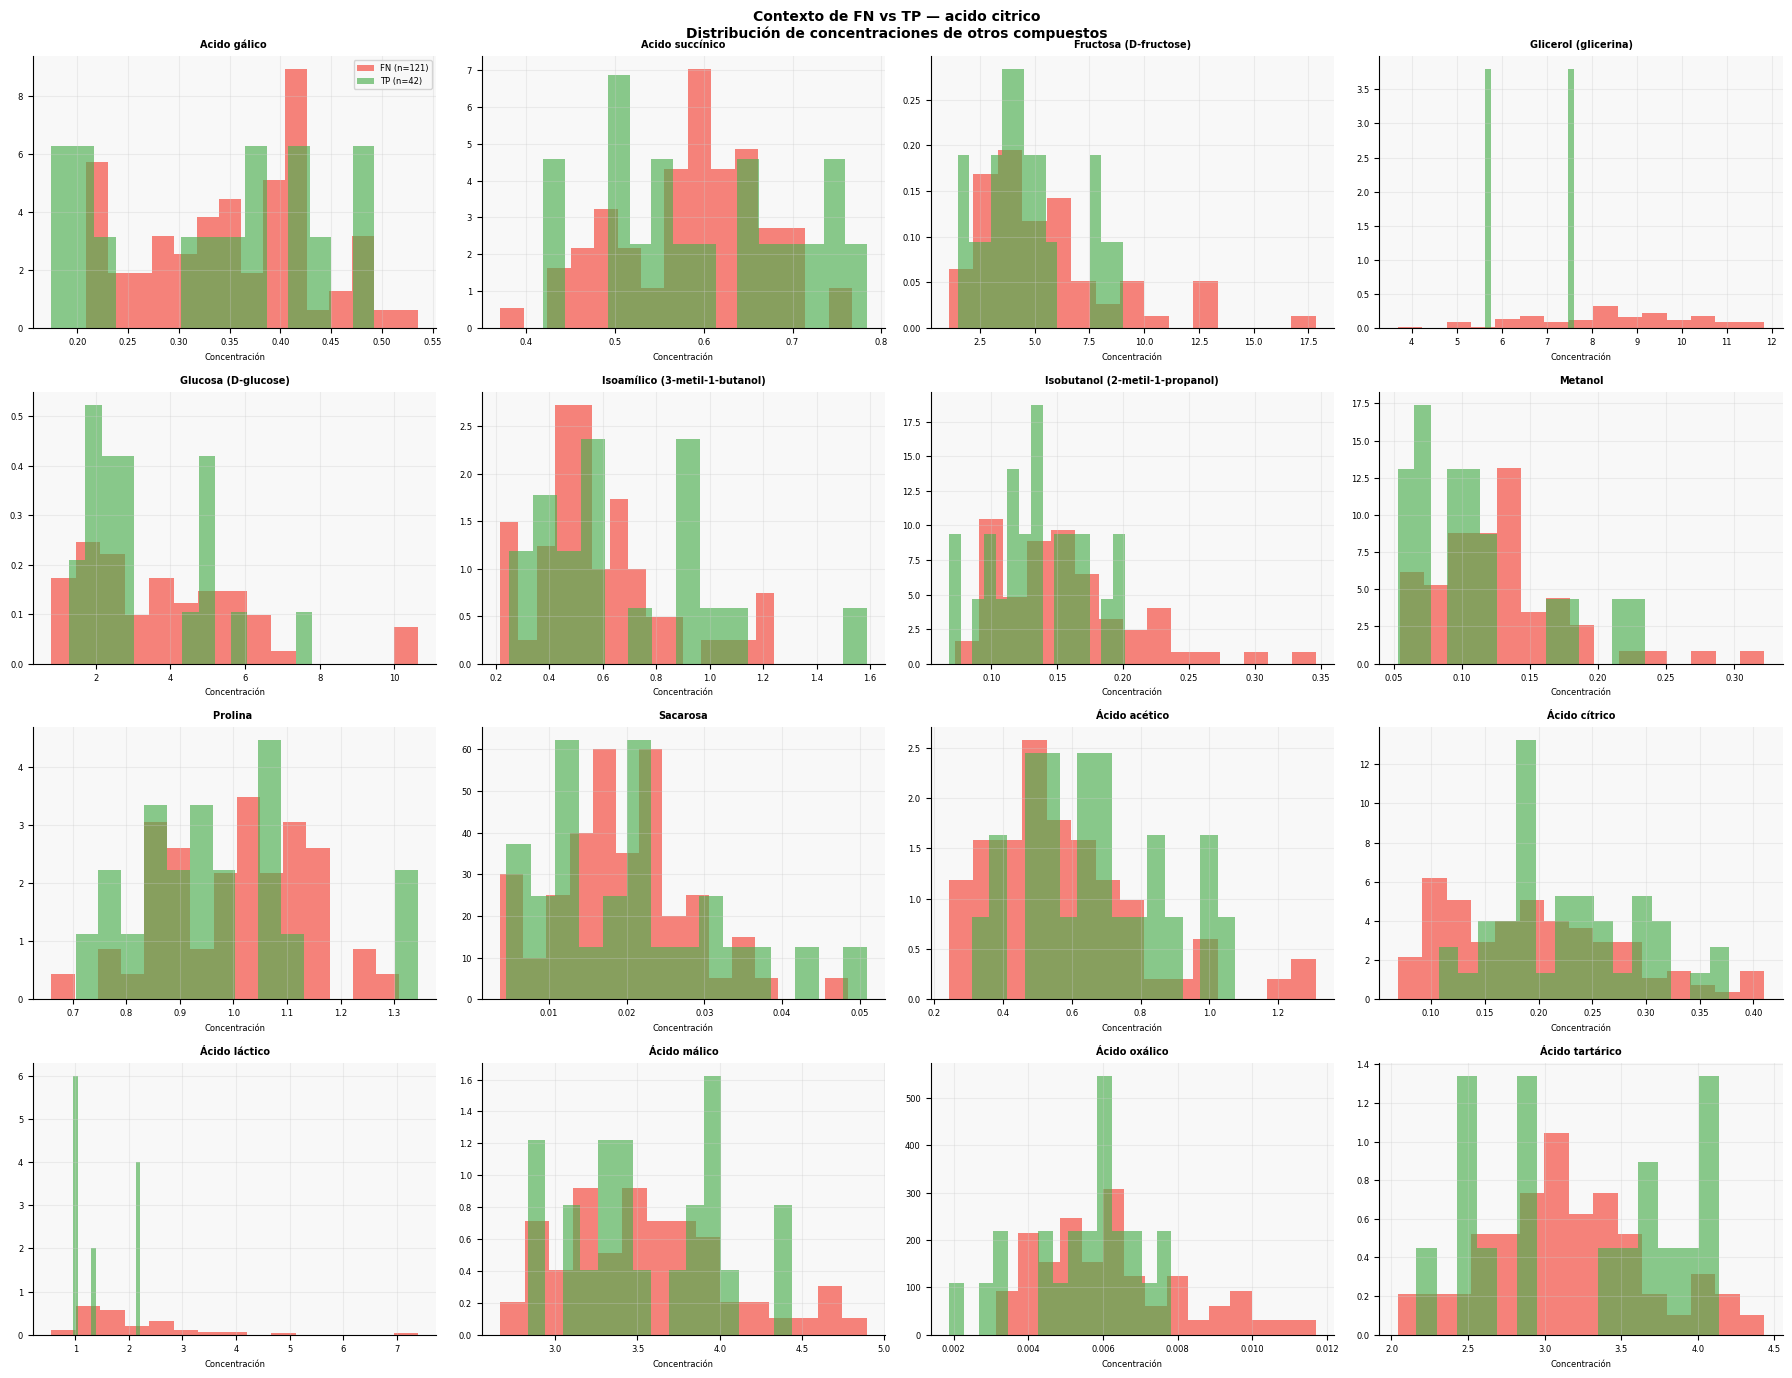

✓ Excel guardado: /content/drive/MyDrive/Simulacion RMN/Resultados/analisis/resultados_20260430_171426.xlsx
Generando PDF...
✓ PDF guardado: /content/drive/MyDrive/Simulacion RMN/Resultados/analisis/reporte_20260430_171426.pdf

✓ Reporte completo
  Pares        : 1500
  Mantenidos   : 1496 (99.7%)
  Rechazados   : 4 (0.3%)
  Directorio   : /content/drive/MyDrive/Simulacion RMN/Resultados/analisis


In [15]:
ANALISIS_DIR = os.path.join(ROOT_DIR, "Resultados", "analisis")

summary = generate_test_report(
    aug_test   = aug_test,
    mean_p     = mean_p,
    std_p      = std_p,
    output_dir = ANALISIS_DIR,
    history    = history,
    master_df  = master_df,
    mix_composition = aug_test["mix_composition"],
    thr        = 0.8,
    sigma_max  = 0.1,
)